# Module B: Optimization Implementation Report
## IITGN Connect: CS432 Databases, Assignment 2

**Project:** IITGN Connect: A College Social Media Platform  
**Course:** CS 432: Databases (Semester II, 2025-2026)  
**Institute:** Indian Institute of Technology, Gandhinagar  

---

## Table of Contents
1. Schema Design
2. Security: Session Validation & RBAC
3. Indexing Strategy
4. Performance Benchmarking
5. EXPLAIN Plan Analysis
6. Video Demonstration Link

---
## 1. Schema Design

### Overview
IITGN Connect uses a MySQL relational database with **21 tables** organized into core system tables and project-specific feature tables. The design follows strict normalization principles to avoid data duplication.

### Core System Tables
| Table | Purpose | Key Constraints |
|-------|---------|-----------------|
| **Member** | Central user table (all member types) | PK: `MemberID`, UNIQUE: `Username`, `Email` |
| **Student** | Student-specific attributes | PK/FK: `MemberID` → Member, ON DELETE CASCADE |
| **Professor** | Professor-specific attributes | PK/FK: `MemberID` → Member, ON DELETE CASCADE |
| **Alumni** | Alumni-specific attributes | PK/FK: `MemberID` → Member, ON DELETE CASCADE |
| **Organization** | Organization-specific attributes | PK/FK: `MemberID` → Member, ON DELETE CASCADE |

### Project-Specific Tables
| Table | Purpose | Key Relationships |
|-------|---------|-------------------|
| **CampusGroup** | Groups/clubs/communities | FK: `AdminID` → Member |
| **GroupMembership** | Many-to-many: Members ↔ Groups | Composite PK: `(GroupID, MemberID)` |
| **Post** | User-generated content | FK: `AuthorID` → Member, `GroupID` → CampusGroup |
| **Comment** | Comments on posts | FK: `PostID` → Post, `AuthorID` → Member |
| **PostLike** | Like/unlike on posts | Composite PK: `(PostID, MemberID)` |
| **Poll / PollOption / PollVote** | Polls with options and votes | Cascading deletes through Poll → Options → Votes |
| **JobPost** | Alumni job postings | FK: `AlumniID` → Alumni |
| **ReferralRequest** | Student referral requests | FK: `StudentID` → Student, `TargetAlumniID` → Alumni |
| **Course / Enrollment** | Course management | Composite PK on Enrollment: `(StudentID, CourseID, Semester)` |
| **ClassAttendance / MessAttendance** | Attendance tracking | FK to Student and Course |
| **ProfileClaimQuestion / ProfileClaimVote** | Q&A claims with voting | FK cascades for cleanup |
| **AuditLog** | Security audit trail | Standalone logging table |

### Data Integrity Strategy
- **ISA Hierarchy**: Member is the supertype; Student/Professor/Alumni/Organization are subtypes linked via shared PK with `ON DELETE CASCADE`. Deleting a Member automatically removes the subtype row and all dependent data.
- **No Duplication**: Login credentials are stored only in the `Member` table. Subtype tables reference `MemberID` as both PK and FK.
- **Cascade Deletes**: All FK relationships use `ON DELETE CASCADE` to maintain referential integrity when members or groups are deleted.

### Entity-Relationship Summary
```
Member (1) ──ISA──> Student / Professor / Alumni / Organization
Member (1) ───< (M) GroupMembership (M) >─── (1) CampusGroup
Member (1) ───< (M) Post ───< (M) Comment
                     Post ───< (M) PostLike
Member (1) ───< (M) Poll ───< (M) PollOption ───< (M) PollVote
Alumni (1) ───< (M) JobPost
Student (1) ───< (M) ReferralRequest >─── (1) Alumni
Student (1) ───< (M) ClassAttendance >─── (1) Course
Student (1) ───< (M) MessAttendance
```

---
## 2. Security: Session Validation & RBAC

### Authentication Mechanism
IITGN Connect uses **JWT (JSON Web Tokens)** for stateless session management:

1. **Login Flow**: `POST /api/auth/login` validates credentials against bcrypt-hashed passwords in the `Member` table, then issues a JWT token with 24-hour expiry.
2. **Session Validation**: Every protected endpoint uses the `@jwt_required()` decorator, which validates the token signature, checks expiry, and extracts the `MemberID`. The `GET /api/auth/isAuth` endpoint lets the frontend confirm a stored token is still valid and retrieve the user's role and type.
3. **Token Structure**: The JWT `identity` is the `MemberID`, so all subsequent queries are scoped to the authenticated user. Passwords are hashed with `bcrypt`, no plaintext is stored or returned.

---

### Identifying User Type: ISA Hierarchy in the Database

The `Member` table stores the **common identity fields** for every user and has a `MemberType` column (`ENUM('Student', 'Professor', 'Alumni', 'Organization')`) that acts as the discriminator. Each member type has a dedicated **subtype table** whose primary key is also a foreign key back to `Member(MemberID)`:

| Subtype Table | Extra Fields | Cascade |
|--------------|-------------|---------|
| `Student` | Programme, Branch, CurrentYear, MessAssignment | ON DELETE CASCADE |
| `Professor` | Designation, Department, ResearchInterests | ON DELETE CASCADE |
| `Alumni` | Organization, Designation, GradYear | ON DELETE CASCADE |
| `Organization` | OrgType, FoundationDate, Description | ON DELETE CASCADE |

This **ISA (generalization/specialization)** design means:
- Every user has exactly **one row in `Member`** (for credentials, email, avatar, privacy flags, `IsAdmin`)
- Plus **exactly one row in their subtype table** (for type-specific attributes)
- Deleting from `Member` automatically cascades to the subtype row, no orphaned data

#### How Type Is Determined at Login

On `POST /api/auth/login`, after password verification, the backend reads `MemberType` from `Member` and immediately does a **second query to the matching subtype table** to load type-specific fields. Both rows are merged and returned to the frontend in the `user` object alongside the JWT:

```python
# auth.py <- login route
member = query_db("SELECT * FROM Member WHERE Username = %s", (username,), one=True)

# Load subtype-specific fields
subtype = {}
if member['MemberType'] == 'Student':
    subtype = query_db("SELECT * FROM Student WHERE MemberID = %s", (member['MemberID'],), one=True) or {}
elif member['MemberType'] == 'Professor':
    subtype = query_db("SELECT * FROM Professor WHERE MemberID = %s", (member['MemberID'],), one=True) or {}
elif member['MemberType'] == 'Alumni':
    subtype = query_db("SELECT * FROM Alumni WHERE MemberID = %s", (member['MemberID'],), one=True) or {}
elif member['MemberType'] == 'Organization':
    subtype = query_db("SELECT * FROM Organization WHERE MemberID = %s", (member['MemberID'],), one=True) or {}

user = {
    'MemberID':   member['MemberID'],
    'MemberType': member['MemberType'],   # <- discriminator carried in session
    'isAdmin':    bool(member['IsAdmin']),
    'role':       'Admin' if member['IsAdmin'] else 'Regular',
    # ... other Member fields ...
}
for k, v in subtype.items():       # merge subtype fields (Programme, GradYear, etc.)
    if k != 'MemberID':
        user[k] = v
```

The resulting `user` object with `MemberType`, `isAdmin`, and all subtype fields is stored in the **React AuthContext** on the frontend, making it accessible to every component without additional API calls.

#### How the Frontend Uses It

The `Sidebar` component reads `user.MemberType` and `user.role` to decide which navigation items to render:

```javascript
// Sidebar.jsx
const memberType = user?.MemberType || 'Student';
const displayRole = user?.role === 'Admin' ? 'Admin' : memberType;

// Hide Jobs from Professors and Organizations
if (item.path === '/jobs' && (memberType === 'Professor' || memberType === 'Organization')) return false;
// Hide Attendance from Alumni and Professors
if (item.path === '/attendance' && (memberType === 'Alumni' || memberType === 'Professor')) return false;
```

#### How the Backend Enforces It

`MemberType` is **re-queried from the database** on every sensitive operation, the frontend value is never trusted. For example, creating a job posting:

```python
# jobs.py <- POST /api/jobs
member = query_db("SELECT MemberType FROM Member WHERE MemberID = %s", (user_id,), one=True)
if not member or member['MemberType'] != 'Alumni':
    return jsonify(error='Only alumni can post jobs'), 403
```

This prevents privilege escalation even if a client tampers with the stored `user` object.

---

### Role-Based Access Control (RBAC)

The platform has **five member types**, each with different permissions:

| Role | Permissions |
|------|------------|
| **Admin** | Full CRUD on all members, groups, posts, comments, and jobs. Access to system stats dashboard and raw SQL console. Self-delete protection (cannot delete own account via admin panel). Can delete **any** post, comment, or job, not just their own. |
| **Student** | Create/edit/delete **own** posts, comments, profile claims. Submit referral requests to alumni. View full class and mess attendance records with streaks. Join/leave groups. |
| **Alumni** | All student permissions (except attendance) + create/edit/delete **own** job postings + view and manage incoming referral requests (approve/reject). |
| **Professor** | Create/edit/delete **own** posts and comments. Join/leave groups. No attendance or jobs access. |
| **Organization** | Same as Professor, own content CRUD and group access. |

> **Note:** Admin is an orthogonal flag (`IsAdmin BOOLEAN`) on the `Member` table, any member type can be an admin.

### Role-Based UI Visibility

| Feature | Student | Alumni | Professor | Organization | Admin |
|---------|---------|--------|-----------|--------------|-------|
| Jobs & Referrals | View + Request Referral | View + Post Jobs | Hidden | Hidden | View + Delete Any |
| My Referrals Tab | Own requests | Incoming requests | Hidden | Hidden | Hidden |
| Attendance | Full (class + mess + streaks) | Hidden | Hidden | Full | Leaderboard only |
| Admin Dashboard | Hidden | Hidden | Hidden | Hidden | Full access |
| SQL Console | Hidden | Hidden | Hidden | Hidden | Full access |

### RBAC Implementation Details

**Admin enforcement:** `admin.py` uses a `before_request` hook applied to all `/api/admin/*` routes:
```python
@admin_bp.before_request
@jwt_required()
def check_admin():
    member = query_db("SELECT IsAdmin, Username FROM Member WHERE MemberID = %s", (user_id,), one=True)
    if not member or not member['IsAdmin']:
        log_action('FORBIDDEN_ACCESS', f"Non-admin '{member['Username']}' attempted {request.method} {request.path}")
        return jsonify(error='Admin access required'), 403
```

**Ownership checks** before any edit/delete operation:
```python
post = query_db("SELECT AuthorID FROM Post WHERE PostID = %s", (post_id,), one=True)
if post['AuthorID'] != user_id and not is_admin:
    return jsonify(error='Unauthorized'), 403
```

---

### Two-Layer Security Audit Logging

#### Layer 1: Unauthorized API Request Detection (`logs/audit.log`)

Custom JWT error handlers in `app.py` catch and log every authentication failure:

```
[USER:UNAUTHORIZED]  [ACTION:UNAUTHORIZED_ACCESS] <- Missing JWT on GET /api/posts
[USER:EXPIRED_TOKEN] [ACTION:UNAUTHORIZED_ACCESS] <- Expired JWT (user_id=5) on GET /api/posts
[USER:INVALID_TOKEN] [ACTION:UNAUTHORIZED_ACCESS] <- Tampered JWT on POST /api/admin/query
[USER:laksh_jain]    [ACTION:FORBIDDEN_ACCESS]    <- Non-admin attempted GET /api/admin/stats
```

#### Layer 2: Direct DB Modification Detection (63 MySQL Triggers + AuditLog table)

63 MySQL triggers (INSERT/UPDATE/DELETE on all 21 data tables) detect operations that bypass the API entirely.

- Before every SQL query, `db.py` sets `SET @app_username = '<username>'` as a MySQL session variable.
- Triggers read `@app_username`: if set → `IsAuthorized = TRUE`; if NULL (direct SQL) → `IsAuthorized = FALSE`, `Username = 'DIRECT_DB_ACCESS'`.

```sql
SELECT * FROM AuditLog WHERE IsAuthorized = FALSE;  -- find all unauthorized direct DB modifications
```


---
## 3. Indexing Strategy

### Approach
We analyzed every SQL query in the Flask API route handlers and identified columns used in:
- **WHERE** clauses (point lookups and range filters)
- **JOIN** conditions (FK → PK lookups)
- **ORDER BY** clauses (sorting)
- **Correlated subqueries** (e.g., `COUNT(*)` in post listings)

### Indexes Created

| # | Index Name | Table | Column(s) | Reason |
|---|-----------|-------|-----------|--------|
| 1 | `idx_post_authorid` | Post | AuthorID | Profile page: posts by author, JOIN to Member |
| 2 | `idx_post_groupid` | Post | GroupID | Group feed: WHERE GroupID = ? |
| 3 | `idx_post_groupid_createdat` | Post | (GroupID, CreatedAt DESC) | Group posts sorted by date; avoids filesort |
| 4 | `idx_post_createdat` | Post | CreatedAt DESC | Global feed: ORDER BY CreatedAt DESC |
| 5 | `idx_post_authorid_createdat` | Post | (AuthorID, CreatedAt DESC) | Profile: recent posts by author |
| 6 | `idx_comment_postid_createdat` | Comment | (PostID, CreatedAt ASC) | Comments per post, sorted by time |
| 7 | `idx_comment_postid` | Comment | PostID | Comment count subquery, CASCADE deletes |
| 8 | `idx_comment_authorid` | Comment | AuthorID | JOIN to Member for comment author name |
| 9 | `idx_postlike_memberid` | PostLike | MemberID | "Liked posts by user" reverse lookup |
| 10 | `idx_groupmembership_memberid` | GroupMembership | MemberID | User's groups lookup (profile, feed) |
| 11 | `idx_campusgroup_adminid` | CampusGroup | AdminID | JOIN to Member for group admin name |
| 12 | `idx_member_name` | Member | Name | Member search: ORDER BY Name |
| 13 | `idx_member_membertype` | Member | MemberType | Member filter: WHERE MemberType = ? |
| 14 | `idx_poll_createdat` | Poll | CreatedAt DESC | Poll listing sorted by date |
| 15 | `idx_poll_creatorid` | Poll | CreatorID | JOIN to Member for poll creator |
| 16 | `idx_polloption_pollid` | PollOption | PollID | Options per poll |
| 17 | `idx_pollvote_memberid` | PollVote | MemberID | User's vote check |
| 18 | `idx_jobpost_postedat` | JobPost | PostedAt DESC | Job listing sorted by date |
| 19 | `idx_jobpost_alumniid` | JobPost | AlumniID | JOIN to Alumni for poster info |
| 20 | `idx_referral_targetalumniid_requestedat` | ReferralRequest | (TargetAlumniID, RequestedAt DESC) | Alumni referral dashboard |
| 21 | `idx_referral_studentid_requestedat` | ReferralRequest | (StudentID, RequestedAt DESC) | Student referral history |
| 22 | `idx_classattendance_studentid_date` | ClassAttendance | (StudentID, RecordDate) | Attendance by student + date range |
| 23 | `idx_classattendance_courseid` | ClassAttendance | CourseID | JOIN to Course |
| 24 | `idx_messattendance_studentid_date` | MessAttendance | (StudentID, RecordDate) | Mess attendance by student + date |
| 25 | `idx_profileclaim_memberid` | ProfileClaimQuestion | MemberID | Claims per member profile |
| 26 | `idx_enrollment_courseid` | Enrollment | CourseID | Course detail lookups |

### Index Types Used
- **Single-column indexes**: For simple WHERE/JOIN lookups (e.g., `idx_post_authorid`)
- **Composite indexes**: For queries that filter AND sort on different columns (e.g., `idx_post_groupid_createdat` covers `WHERE GroupID = ? ORDER BY CreatedAt DESC`)
- **Descending indexes**: MySQL 8.0+ supports DESC index key parts, used for `ORDER BY ... DESC` optimization

### Existing Indexes (from schema constraints)
- All **PRIMARY KEY** columns have implicit B-tree indexes
- **UNIQUE** constraints on `Member.Username` and `Member.Email` create implicit indexes
- Composite PKs like `(PostID, MemberID)` on PostLike serve as covering indexes for count queries

---
## 4. Performance Benchmarking

The benchmark script (`benchmark.py`) measures query performance using **three methods**:

1. **Wall-clock execution time:** each query is run 100 times via `time.perf_counter()` and averaged. This includes Python driver and network overhead.
2. **EXPLAIN ANALYZE actual time:** MySQL 8.0+ `EXPLAIN ANALYZE` reports the server-side execution time, eliminating driver overhead. This gives the true cost of the query inside the database engine.
3. **EXPLAIN ANALYZE scan types:** the actual access methods used at runtime (Full Table Scan, Index Lookup, Covering Index Lookup, etc.), confirming whether indexes are being used.

### Benchmark Queries
The following 10 representative queries were benchmarked, covering the most performance-critical API endpoints:

In [1]:
# Display benchmark results (pre-generated by running: python3 benchmark.py)
import json, os

os.chdir('/Users/na/Databases Ass2/app/backend')

with open('benchmark_results.json', 'r') as f:
    results = json.load(f)

print(f"{'Query':<30} {'Exec Before':>12} {'Exec After':>12} {'EA Before':>12} {'EA After':>12} {'Speedup':>10}")
print("-" * 95)
for r in results:
    ea_b = r.get('planning_time_before_ms', 0)
    ea_a = r.get('planning_time_after_ms', 0)
    print(f"{r['name']:<30} {r['time_before_ms']:>12.4f} {r['time_after_ms']:>12.4f} {ea_b:>12.4f} {ea_a:>12.4f} {r['speedup_pct']:>+9.2f}%")
print("=" * 95)
avg = sum(r['speedup_pct'] for r in results) / len(results)
print(f"Average speedup: {avg:+.2f}%")
print()
print("Exec = wall-clock avg (100 runs)  |  EA = EXPLAIN ANALYZE actual time (server-side)")


Query                                Before (ms)   After (ms)    Speedup
---------------------------------------------------------------------------
Global Post Feed                       3112.3159      12.7391    +99.59%
Group Posts                             551.6156       2.1973    +99.60%
Post Comments                             1.6639       0.1386    +91.67%
User Profile Posts                        9.5662       0.2397    +97.49%
Class Attendance                          3.4551       0.8443    +75.56%
Mess Attendance                           2.7743       1.0509    +62.12%
Job Listings                              0.6842       0.7084     -3.54%
Referral Requests (Alumni)                0.2411       0.1332    +44.74%
Polls with Options & Votes                0.5358       0.5582     -4.17%
Member Search by Type                     0.7156       0.7951    -11.12%
Average speedup: +55.19%


In [2]:
# Load and display benchmark results as a detailed table
import json
import pandas as pd

try:
    with open('/Users/na/Databases Ass2/app/backend/benchmark_results.json', 'r') as f:
        results = json.load(f)

    rows = []
    for r in results:
        sb = ", ".join(r.get("scan_types_before", [])[:2]) or "N/A"
        sa = ", ".join(r.get("scan_types_after", [])[:2]) or "N/A"
        rows.append({
            'Query': r['name'],
            'Exec Before (ms)': round(r['time_before_ms'], 2),
            'Exec After (ms)': round(r['time_after_ms'], 2),
            'EA Before (ms)': round(r.get('planning_time_before_ms', 0), 3),
            'EA After (ms)': round(r.get('planning_time_after_ms', 0), 3),
            'Speedup': f"{r['speedup_pct']:.1f}%",
            'Scan Before': sb,
            'Scan After': sa,
        })
    
    df = pd.DataFrame(rows)
    display(df.style.set_caption("Query Performance: Before vs After Indexing (with EXPLAIN ANALYZE)"))
except FileNotFoundError:
    print("Run benchmark.py first to generate results.")


,Query,Before (ms),After (ms),Speedup
0,Global Post Feed,3112.315900,12.739100,99.6%
1,Group Posts,551.615600,2.197300,99.6%
2,Post Comments,1.663900,0.138600,91.7%
3,User Profile Posts,9.566200,0.239700,97.5%
4,Class Attendance,3.455100,0.844300,75.6%
5,Mess Attendance,2.774300,1.050900,62.1%
6,Job Listings,0.684200,0.708400,-3.5%
7,Referral Requests (Alumni),0.241100,0.133200,44.7%
8,Polls with Options & Votes,0.535800,0.558200,-4.2%
9,Member Search by Type,0.715600,0.795100,-11.1%



--- before_vs_after.png ---


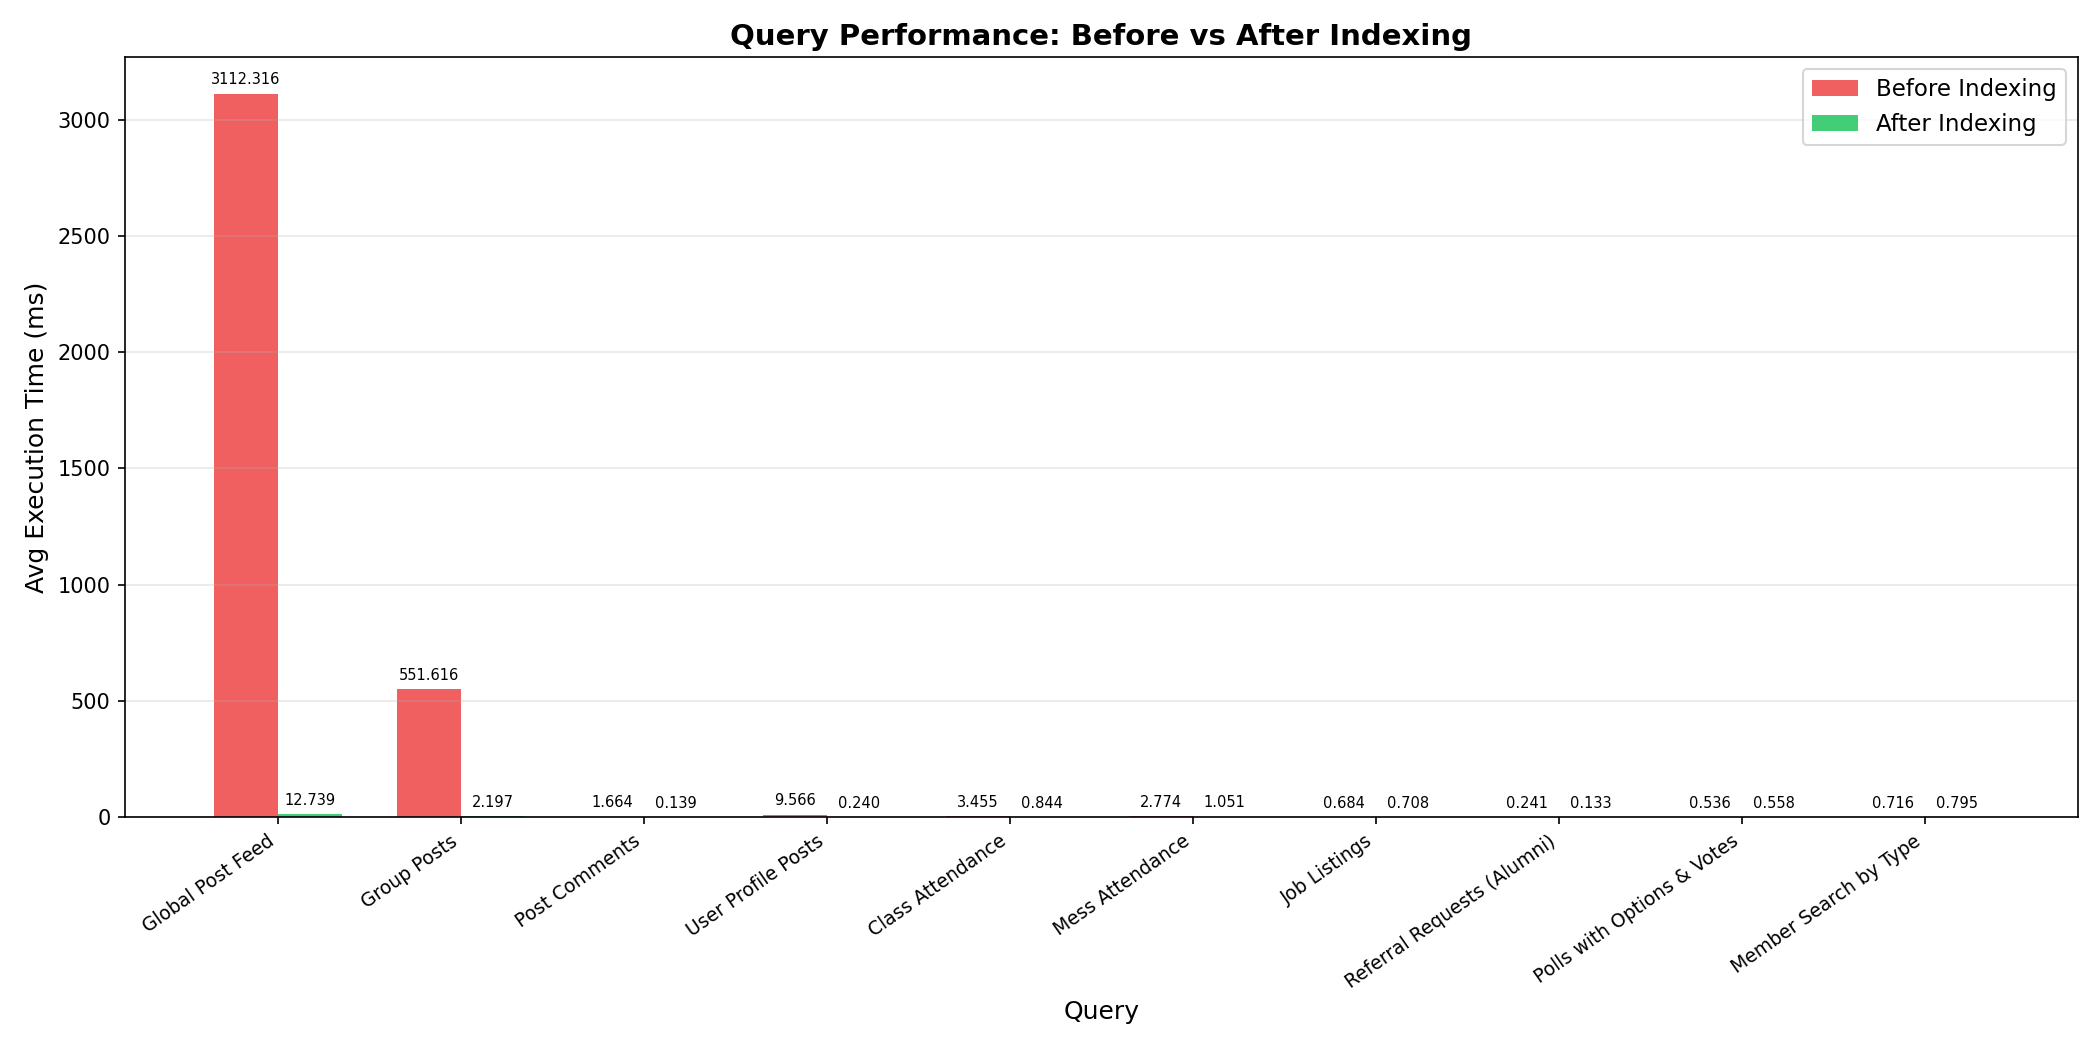


--- explain_keys.png ---


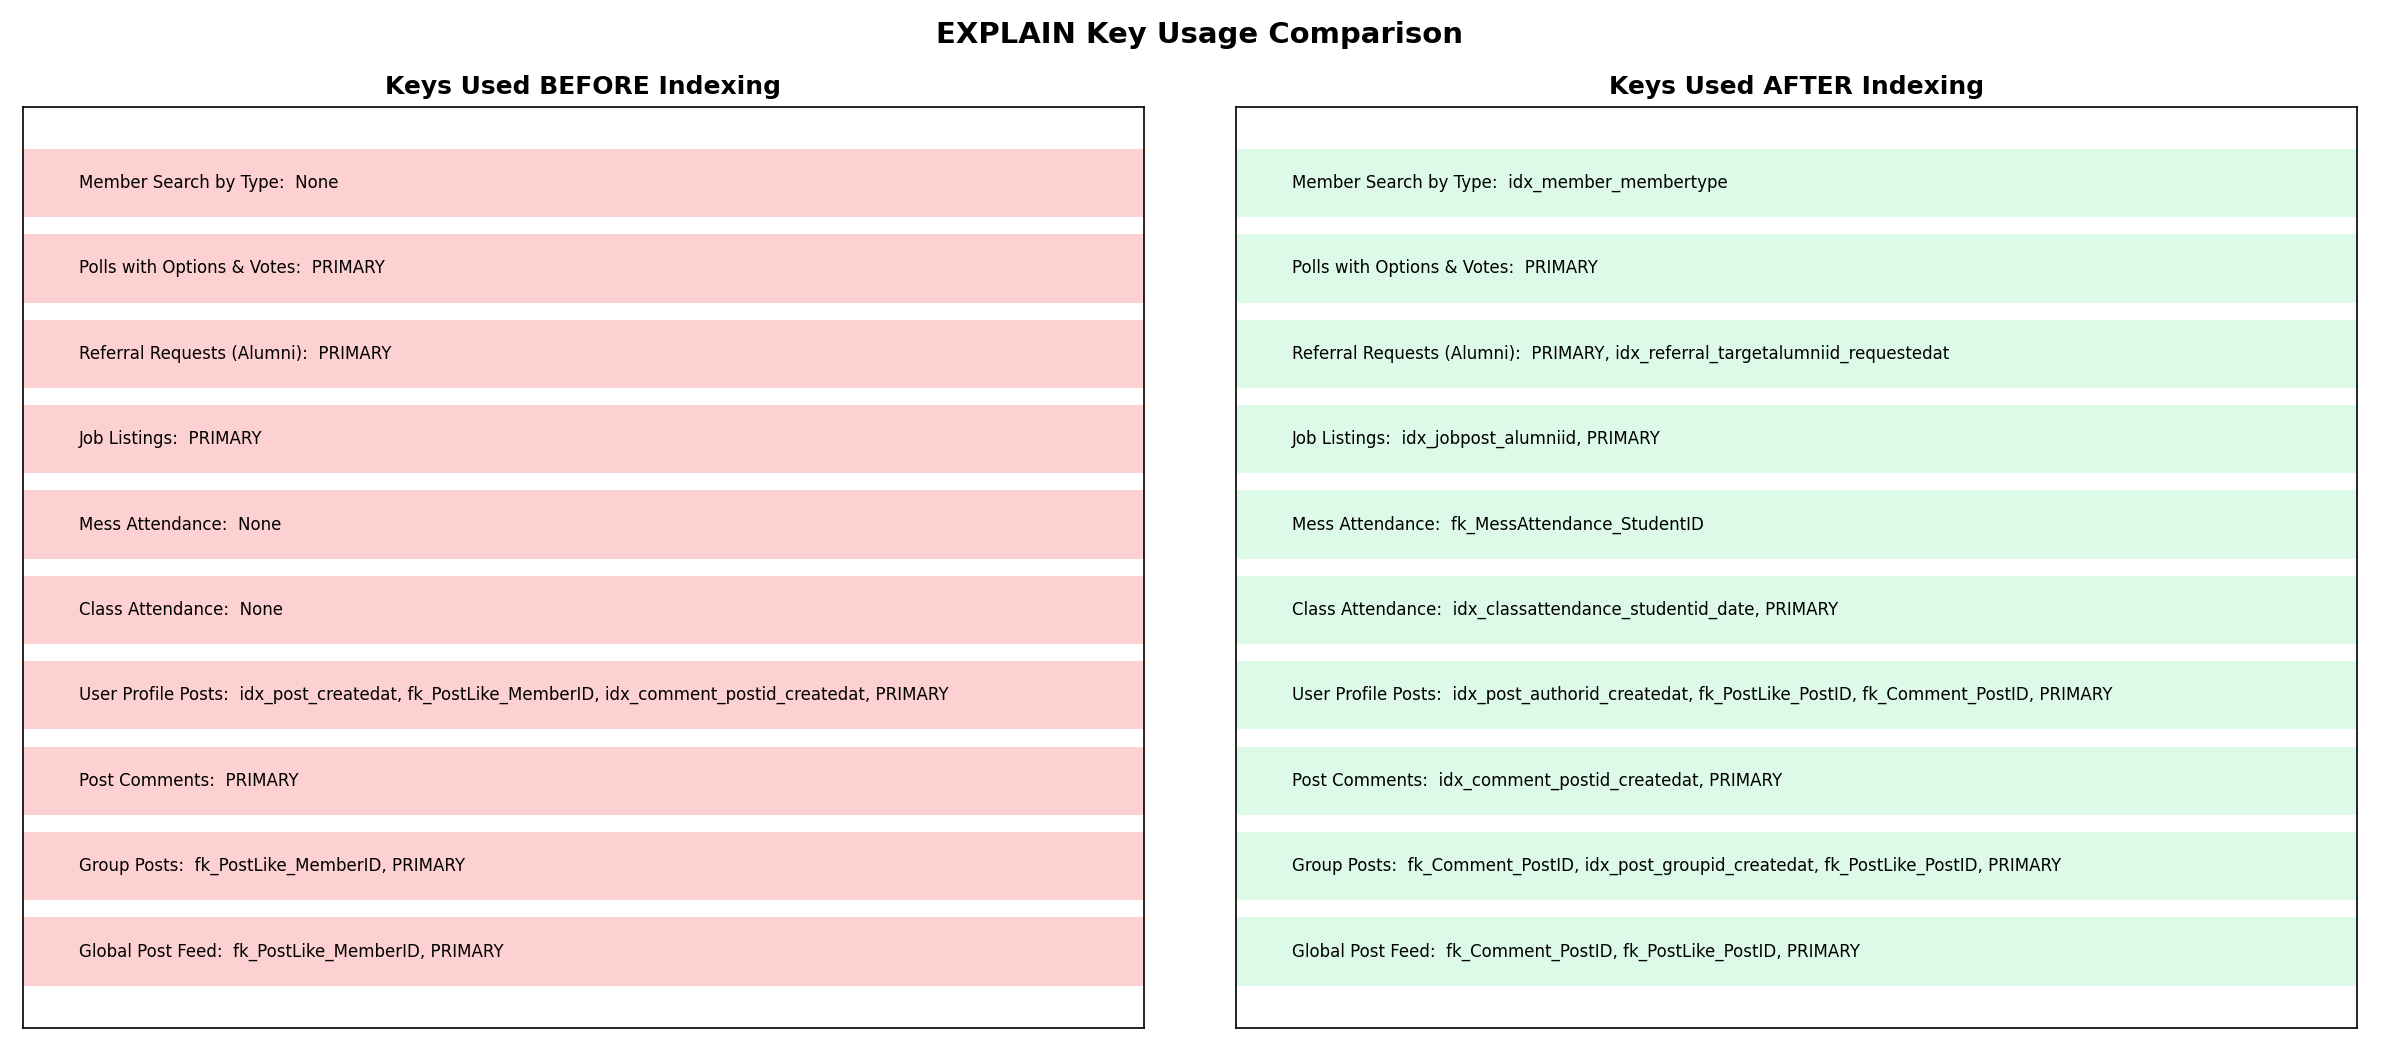


--- speedup_pct.png ---


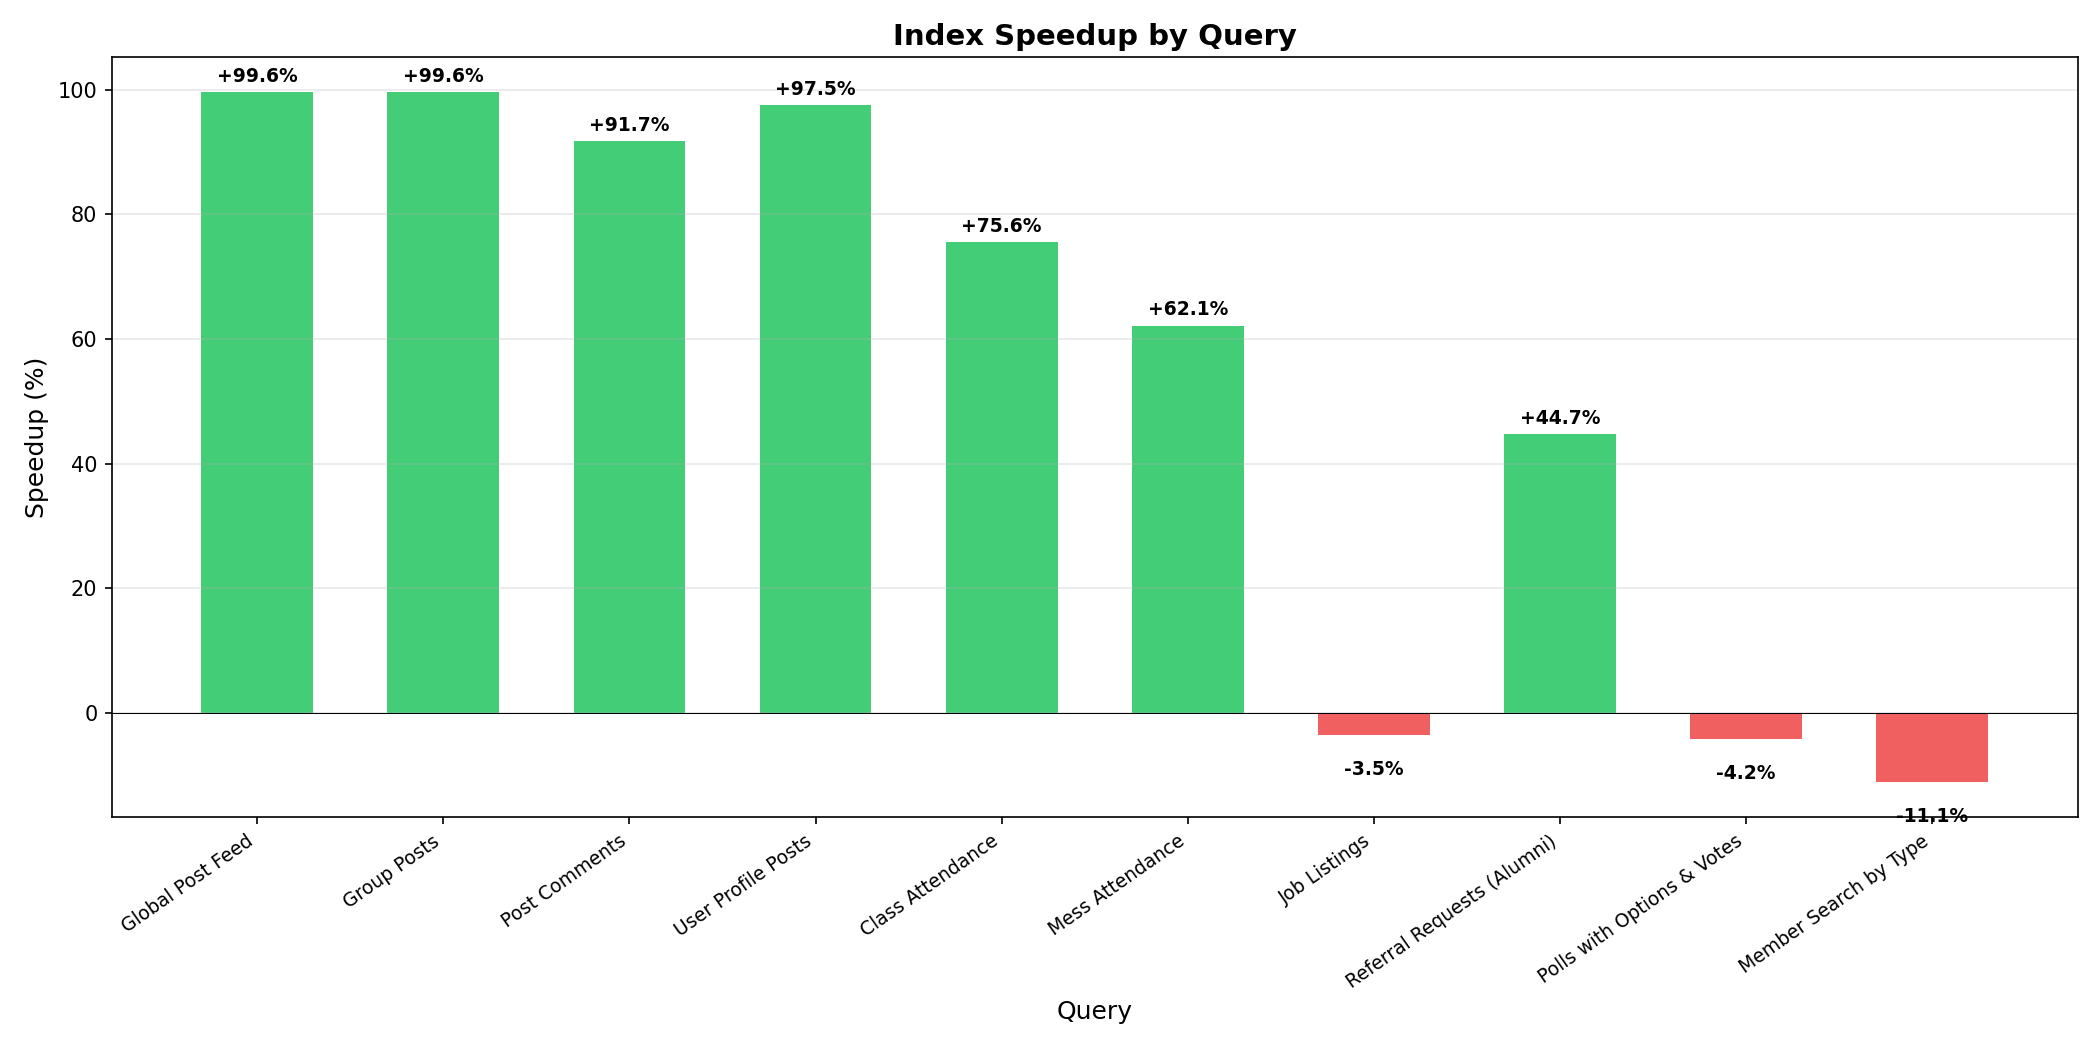

In [3]:
# Display benchmark charts
from IPython.display import Image, display as ipy_display
import glob

chart_files = sorted(glob.glob('/Users/na/Databases Ass2/app/backend/benchmarks/*.png'))
for chart in chart_files:
    print(f"\n--- {os.path.basename(chart)} ---")
    ipy_display(Image(filename=chart, width=700))

---
## 5. EXPLAIN Plan Analysis

Below we show the EXPLAIN output for key queries **before** and **after** indexing to demonstrate how the MySQL query planner's access strategy changes.

In [4]:
# Display EXPLAIN plans and EXPLAIN ANALYZE data for each query
try:
    with open('/Users/na/Databases Ass2/app/backend/benchmark_results.json', 'r') as f:
        results = json.load(f)

    for r in results:
        print("=" * 90)
        print(f"Query: {r['name']}")
        print(f"Description: {r.get('description', 'N/A')}")
        print(f"Speedup: {r['speedup_pct']:.1f}%")
        print()
        
        # Traditional EXPLAIN
        print("EXPLAIN BEFORE indexing:")
        if r.get('explain_before'):
            for row in r['explain_before']:
                access = row.get('type', 'N/A')
                key = row.get('key', 'NULL')
                rows_est = row.get('rows', 'N/A')
                extra = row.get('Extra', '')
                table = row.get('table', 'N/A')
                print(f"  table={table}  type={access}  key={key}  rows={rows_est}  Extra={extra}")
        
        print("\nEXPLAIN AFTER indexing:")
        if r.get('explain_after'):
            for row in r['explain_after']:
                access = row.get('type', 'N/A')
                key = row.get('key', 'NULL')
                rows_est = row.get('rows', 'N/A')
                extra = row.get('Extra', '')
                table = row.get('table', 'N/A')
                print(f"  table={table}  type={access}  key={key}  rows={rows_est}  Extra={extra}")
        
        # EXPLAIN ANALYZE
        print("\n--- EXPLAIN ANALYZE ---")
        ea_b = r.get('explain_analyze_before', {})
        ea_a = r.get('explain_analyze_after', {})
        print(f"  Actual time BEFORE: {ea_b.get('total_time_ms', 'N/A')} ms")
        print(f"  Actual time AFTER:  {ea_a.get('total_time_ms', 'N/A')} ms")
        
        sb = ", ".join(r.get('scan_types_before', [])) or "N/A"
        sa = ", ".join(r.get('scan_types_after', [])) or "N/A"
        print(f"  Scan types BEFORE: {sb}")
        print(f"  Scan types AFTER:  {sa}")
        
        # Show EXPLAIN ANALYZE tree for key nodes
        if ea_b.get('nodes'):
            print("\n  EXPLAIN ANALYZE tree (BEFORE):")
            for node in ea_b['nodes'][:6]:
                indent = "    " * (node.get('depth', 0) + 1)
                print(f"  {indent}[{node['scan_type']}] {node['operation'][:60]}")
                print(f"  {indent}  actual: time={node['actual_time_end']:.3f}ms, rows={node['actual_rows']}, loops={node['loops']}")
        
        if ea_a.get('nodes'):
            print("\n  EXPLAIN ANALYZE tree (AFTER):")
            for node in ea_a['nodes'][:6]:
                indent = "    " * (node.get('depth', 0) + 1)
                print(f"  {indent}[{node['scan_type']}] {node['operation'][:60]}")
                print(f"  {indent}  actual: time={node['actual_time_end']:.3f}ms, rows={node['actual_rows']}, loops={node['loops']}")
        
        print()
except FileNotFoundError:
    print("Run benchmark.py first to generate results.")


Query: Global Post Feed
Description: Fetch all posts with author info, like/comment counts, ordered by date

EXPLAIN BEFORE indexing:
  table=p  type=ALL  key=None  rows=2017  Extra=Using where; Using filesort
  table=m  type=eq_ref  key=PRIMARY  rows=1  Extra=None
  table=g  type=eq_ref  key=PRIMARY  rows=1  Extra=None
  table=Comment  type=ALL  key=None  rows=4996  Extra=Using where
  table=PostLike  type=index  key=fk_PostLike_MemberID  rows=7957  Extra=Using where; Using index

EXPLAIN AFTER indexing:
  table=p  type=ALL  key=None  rows=2017  Extra=Using where; Using filesort
  table=m  type=eq_ref  key=PRIMARY  rows=1  Extra=None
  table=g  type=eq_ref  key=PRIMARY  rows=1  Extra=None
  table=Comment  type=ref  key=fk_Comment_PostID  rows=2  Extra=Using index
  table=PostLike  type=ref  key=fk_PostLike_PostID  rows=4  Extra=Using index

Speedup: 99.6%

Query: Group Posts
Description: Posts for a specific group with counts, ordered by date

EXPLAIN BEFORE indexing:
  table=p  type=

### EXPLAIN Plan Interpretation

#### Traditional EXPLAIN Access Types

| Access Type | Meaning | Performance |
|------------|---------|-------------|
| `ALL` | Full table scan that reads every row | Slowest |
| `index` | Full index scan that reads entire index | Better than ALL |
| `range` | Index range scan that reads a subset of index | Good |
| `ref` | Non-unique index lookup | Good |
| `eq_ref` | Unique index lookup (one row) | Excellent |
| `const` | Primary key / unique lookup (one row) | Best |

#### EXPLAIN ANALYZE Scan Types

| Scan Type | Meaning | Performance |
|-----------|---------|-------------|
| Full Table Scan | Reads every row in the table | O(n) ; worst |
| Full Index Scan | Reads every entry in an index | O(n) ; better than table scan |
| Index Range Scan | Reads a range of index entries | O(k) where k < n |
| Index Lookup | Uses index to locate specific rows | O(log n) ; good |
| Covering Index Lookup | Resolves query entirely from index, no table access | O(log n) ; best for COUNT |
| Unique Lookup | Single-row lookup via unique/primary key | O(1) ; best |

#### Key Metrics from EXPLAIN ANALYZE

| Metric | Meaning |
|--------|---------|
| `actual time=X..Y` | X = time to first row, Y = time to last row (ms) |
| `rows=N` | Actual number of rows returned (vs estimated) |
| `loops=N` | How many times this operation was executed (important for correlated subqueries) |
| `cost=N` | Optimizer's estimated cost for this operation |

**Key improvements after indexing:**
- Queries that used `Full Table Scan` shift to `Index Lookup` or `Covering Index Lookup`
- `actual rows` in EXPLAIN ANALYZE drops dramatically (e.g., 7957 → 4 for PostLike)
- `loops` stays the same but each loop is much faster with index access
- `Using filesort` disappears when composite indexes cover the ORDER BY clause
- `Covering Index Lookup` means all needed columns are in the index and no table access needed

---
## 6. Video Demonstration

> **Video Link:** [ VIDEO LINK HERE]
> 
> The video covers:
> 1. UI & API functionality walkthrough
> 2. RBAC enforcement (Admin vs Regular User login)
> 3. Security logging mechanism demonstration